<a href="https://colab.research.google.com/github/ldenarbonne/MLOpengouins/blob/1_productionizing_ML/bitcoin_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Projet Data Artefact/Filled_dataset.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,timestamp,open,high,low,close,volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [4]:
##Import libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px




import os

In [6]:
##Data Exploration
print(df.head())
print(df.info())
print(df.describe())

      timestamp  open  high   low  close  volume
0  1.325412e+09  4.58  4.58  4.58   4.58     0.0
1  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2  1.325412e+09  4.58  4.58  4.58   4.58     0.0
3  1.325412e+09  4.58  4.58  4.58   4.58     0.0
4  1.325412e+09  4.58  4.58  4.58   4.58     0.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7333361 entries, 0 to 7333360
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   timestamp  float64
 1   open       float64
 2   high       float64
 3   low        float64
 4   close      float64
 5   volume     float64
dtypes: float64(6)
memory usage: 335.7 MB
None
          timestamp          open          high           low         close  \
count  7.333361e+06  7.333361e+06  7.333361e+06  7.333361e+06  7.333361e+06   
mean   1.545413e+09  2.139632e+04  2.140400e+04  2.138844e+04  2.139632e+04   
std    1.270175e+08  3.005749e+04  3.006569e+04  3.004917e+04  3.005749e+04   
min    1.325412e+09  3.800000e+00  3.80

In [9]:
df['date'] = pd.to_datetime(df['date'])

# Filter the exact date range
mask = (df['date'] >= '2025-03-13') & (df['date'] <= '2025-03-17')
df_march = df[mask]

# Plot
plt.figure(figsize=(12,6))
plt.plot(df_march['date'], df_march['close'])
plt.title('Bitcoin Closing Price (2025-03-13 to 2025-03-17)')
plt.xlabel('date')
plt.ylabel('Closing Price (USD)')
plt.grid(True)
plt.show()

KeyError: 'date'

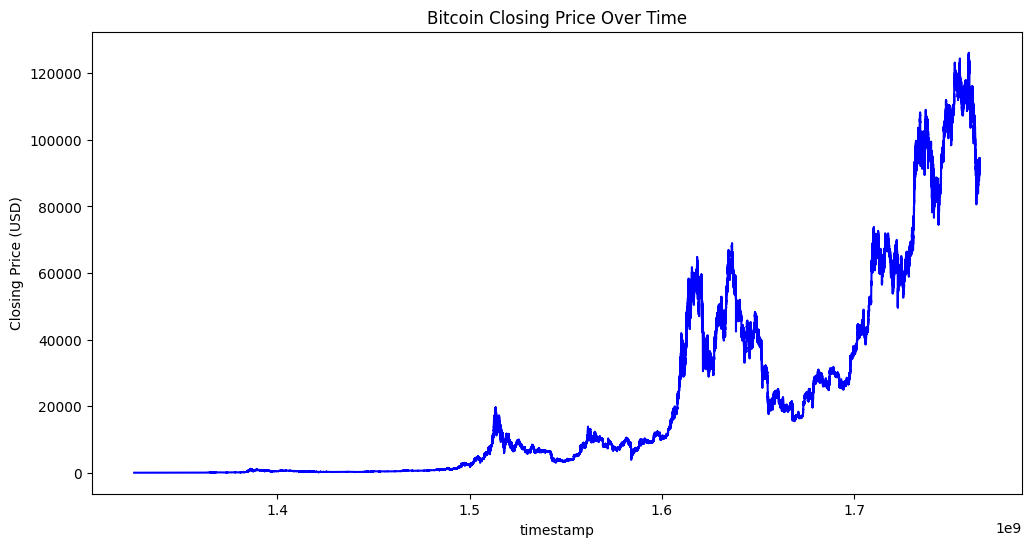

In [10]:
#plot the closing price over time
plt.figure(figsize=(12,6))
plt.plot(df['timestamp'], df['close'], color='blue')
plt.title('Bitcoin Closing Price Over Time')
plt.xlabel('timestamp')
plt.ylabel('Closing Price (USD)')
plt.show()

In [11]:
#convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

In [12]:
##Data Exploration
print(df.head())
print(df.info())
print(df.describe())

            timestamp  open  high   low  close  volume
0 2012-01-01 10:01:00  4.58  4.58  4.58   4.58     0.0
1 2012-01-01 10:02:00  4.58  4.58  4.58   4.58     0.0
2 2012-01-01 10:03:00  4.58  4.58  4.58   4.58     0.0
3 2012-01-01 10:04:00  4.58  4.58  4.58   4.58     0.0
4 2012-01-01 10:05:00  4.58  4.58  4.58   4.58     0.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7333361 entries, 0 to 7333360
Data columns (total 6 columns):
 #   Column     Dtype         
---  ------     -----         
 0   timestamp  datetime64[ns]
 1   open       float64       
 2   high       float64       
 3   low        float64       
 4   close      float64       
 5   volume     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 335.7 MB
None
                           timestamp          open          high  \
count                        7333361  7.333361e+06  7.333361e+06   
mean   2018-12-21 17:20:59.999987712  2.139632e+04  2.140400e+04   
min              2012-01-01 10:01:00  3.

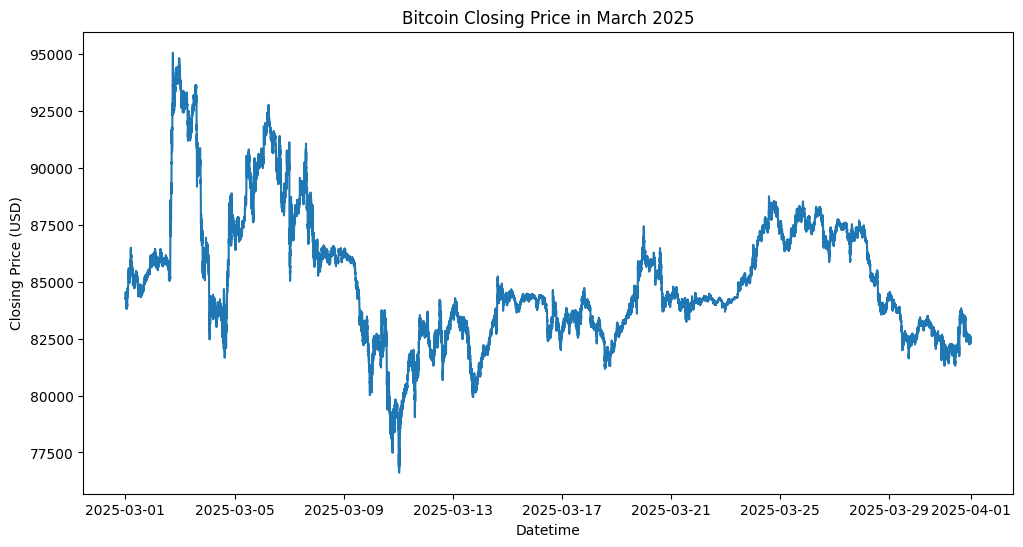

In [13]:
plt.figure(figsize=(12,6))

df_march = df[(df['timestamp'].dt.year == 2025) &
              (df['timestamp'].dt.month == 3)]

plt.plot(df_march['timestamp'], df_march['close'])
plt.title('Bitcoin Closing Price in March 2025')
plt.xlabel('Datetime')
plt.ylabel('Closing Price (USD)')
plt.show()

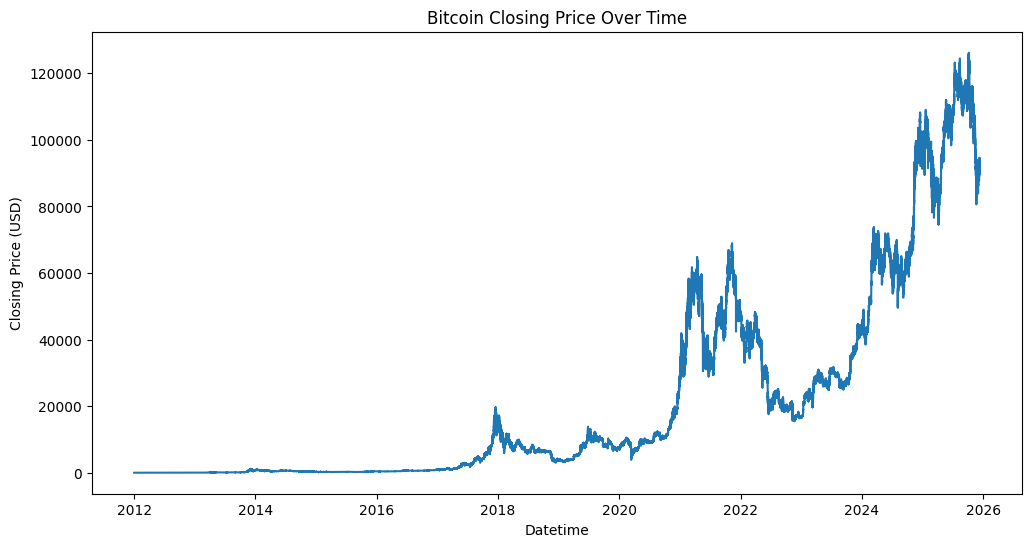

In [14]:
#display the chart for the whole history
plt.figure(figsize=(12,6))
plt.plot(df['timestamp'], df['close'])
plt.title('Bitcoin Closing Price Over Time')
plt.xlabel('Datetime')
plt.ylabel('Closing Price (USD)')
plt.show()

In [15]:
#identify missing timestamps
df = df.set_index('timestamp')
all_timestamps = pd.date_range(start=df.index.min(), end=df.index.max(), freq='min')
missing_timestamps = all_timestamps.difference(df.index)
print(f"Number of missing timestamps: {len(missing_timestamps)}")
print(missing_timestamps)
#fill missing timestamps with NaN values
df = df.reindex(all_timestamps)
print(df.isnull().sum())


Number of missing timestamps: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='min')
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [16]:
#timi based interlopation to fill missing values
df.interpolate(method='time', inplace=True)
print(df.isnull().sum())
#reset index
df = df.reset_index().rename(columns={'index': 'Timestamp'})
print(df.head())
#plot the closing price over time after filling missing values
plt.figure(figsize=(12,6))
plt.plot(df['Timestamp'], df['Close'], color='green')
plt.title('Bitcoin Closing Price Over Time (After Filling Missing Values)')
plt.xlabel('Timestamp')
plt.ylabel('Closing Price (USD)')
plt.show()

open      0
high      0
low       0
close     0
volume    0
dtype: int64
            Timestamp  open  high   low  close  volume
0 2012-01-01 10:01:00  4.58  4.58  4.58   4.58     0.0
1 2012-01-01 10:02:00  4.58  4.58  4.58   4.58     0.0
2 2012-01-01 10:03:00  4.58  4.58  4.58   4.58     0.0
3 2012-01-01 10:04:00  4.58  4.58  4.58   4.58     0.0
4 2012-01-01 10:05:00  4.58  4.58  4.58   4.58     0.0


KeyError: 'Close'

<Figure size 1200x600 with 0 Axes>

In [17]:
#plot log returns with time stamps converted to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
plt.figure(figsize=(12,6))
plt.plot(df['Timestamp'], df['Log_Returns'], color='orange')
plt.title('Bitcoin Log Returns Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Log Returns')
plt.show()

KeyError: 'Close'

In [18]:
# Convertir timestamps Unix en datetime et définir l'index
#df['datetime'] = pd.to_datetime(df['Timestamp'], unit='s')
#df.set_index('datetime', inplace=True)
# Assurez-vous que l'index de New_dataest correct
#New_data['datetime'] = pd.to_datetime(df['Timestamp'], unit='s')
#New_data.set_index('datetime', inplace=True)
#21 h 43
print(df.index[:10])   # Affiche les 10 premiers index
print(type(df.index))

RangeIndex(start=0, stop=10, step=1)
<class 'pandas.core.indexes.range.RangeIndex'>


In [ ]:
df.shape

In [19]:
import pandas as pd
# Assurer que l'index est datetime
df.index = pd.to_datetime(df.index)
df = df.sort_index()
# Début exact du trou (confirmé par ton analyse)
start_gap = pd.to_datetime("2025-03-15 00:01:00")
# Créer le dataset propre (continu, sans trou)
best_data = df[df.index < start_gap]
# Vérifications
print("Dernier timestamp conservé :", best_data.index.max())
print("Nombre de lignes conservées :", len(best_data))
# Optionnel : aperçu
best_data.head(), best_data.tail()

Dernier timestamp conservé : 1970-01-01 00:00:00.007333360
Nombre de lignes conservées : 7333361


(                                        Timestamp  open  high   low  close  \
 1970-01-01 00:00:00.000000000 2012-01-01 10:01:00  4.58  4.58  4.58   4.58   
 1970-01-01 00:00:00.000000001 2012-01-01 10:02:00  4.58  4.58  4.58   4.58   
 1970-01-01 00:00:00.000000002 2012-01-01 10:03:00  4.58  4.58  4.58   4.58   
 1970-01-01 00:00:00.000000003 2012-01-01 10:04:00  4.58  4.58  4.58   4.58   
 1970-01-01 00:00:00.000000004 2012-01-01 10:05:00  4.58  4.58  4.58   4.58   
 
                                volume  
 1970-01-01 00:00:00.000000000     0.0  
 1970-01-01 00:00:00.000000001     0.0  
 1970-01-01 00:00:00.000000002     0.0  
 1970-01-01 00:00:00.000000003     0.0  
 1970-01-01 00:00:00.000000004     0.0  ,
                                         Timestamp     open     high      low  \
 1970-01-01 00:00:00.007333356 2025-12-11 00:37:00  91671.0  91671.0  91608.0   
 1970-01-01 00:00:00.007333357 2025-12-11 00:38:00  91656.0  91660.0  91443.0   
 1970-01-01 00:00:00.007333358 202

In [ ]:
print(df.index[:10])   # Affiche les 10 premiers index
print(type(df.index))

In [20]:
# --- Time-based interpolation to fill missing values for March 2025 ---

# Filter March 2025 data
df_march = df[(df['Timestamp'].dt.year == 2025) &
              (df['Timestamp'].dt.month == 3)].copy()

# Ensure Timestamp is datetime
df_march['Timestamp'] = pd.to_datetime(df_march['Timestamp'])

# Set Timestamp as index
df_march = df_march.set_index('Timestamp')

# Create a complete index with 1-minute frequency
all_timestamps_march = pd.date_range(start=df_march.index.min(),
                                     end=df_march.index.max(),
                                     freq='1min')

# Identify missing timestamps
missing_timestamps_march = all_timestamps_march.difference(df_march.index)
print(f"Number of missing timestamps in March 2025: {len(missing_timestamps_march)}")
print(missing_timestamps_march)

# Reindex to insert missing timestamps (NaN Close values)
df_march = df_march.reindex(all_timestamps_march)

# Check missing values before interpolation
print("Missing values before interpolation:")
print(df_march.isnull().sum())

# Time-based interpolation
df_march.interpolate(method='time', inplace=True)

# Check missing values after interpolation
print("Missing values after interpolation:")
print(df_march.isnull().sum())

# --- Plot the results ---
plt.figure(figsize=(12, 6))
plt.plot(df_march.index, df_march['Close'], color='orange')
plt.title('Bitcoin Closing Price in March 2025 (After Filling Missing Values)')
plt.xlabel('Datetime')
plt.ylabel('Closing Price (USD)')
plt.show()

Number of missing timestamps in March 2025: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='min')
Missing values before interpolation:
open      0
high      0
low       0
close     0
volume    0
dtype: int64
Missing values after interpolation:
open      0
high      0
low       0
close     0
volume    0
dtype: int64


KeyError: 'Close'

<Figure size 1200x600 with 0 Axes>

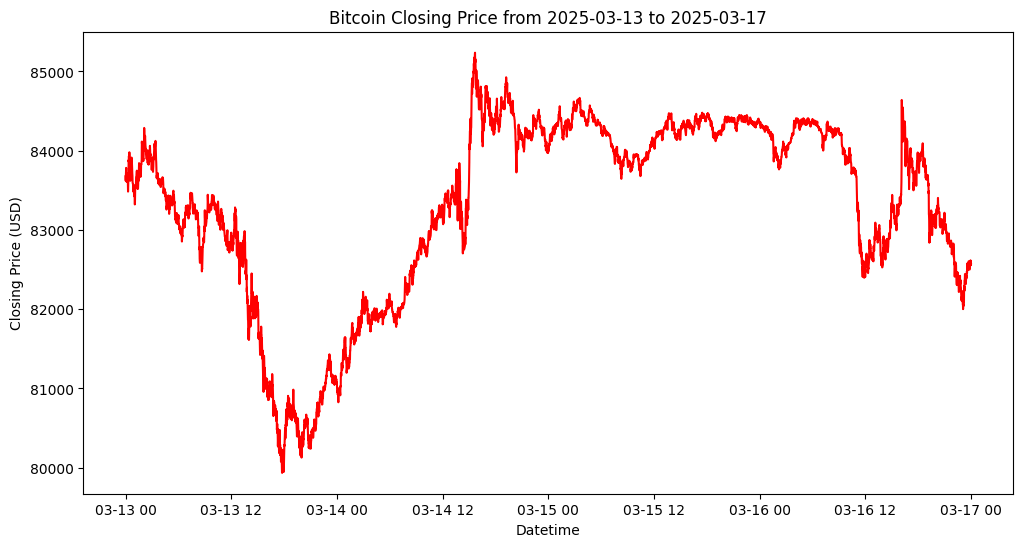

In [22]:
# plot de bitcoin price between 2025-03-13 and 2025-03-17
df_march_period = df_march[(df_march.index >= '2025-03-13') & (df_march.index <= '2025-03-17')]
plt.figure(figsize=(12, 6))
plt.plot(df_march_period.index, df_march_period['close'], color='red')
plt.title('Bitcoin Closing Price from 2025-03-13 to 2025-03-17')
plt.xlabel('Datetime')
plt.ylabel('Closing Price (USD)')
plt.show()

In [23]:
import pandas as pd

# show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# now print your slice
print(df_march_period)


                        open     high      low    close     volume
2025-03-13 00:00:00  83677.0  83677.0  83677.0  83677.0   0.000533
2025-03-13 00:01:00  83654.0  83654.0  83612.0  83621.0   0.262363
2025-03-13 00:02:00  83591.0  83684.0  83591.0  83684.0   0.000947
2025-03-13 00:03:00  83726.0  83731.0  83726.0  83731.0   0.000377
2025-03-13 00:04:00  83764.0  83783.0  83764.0  83783.0   0.005260
2025-03-13 00:05:00  83704.0  83704.0  83661.0  83668.0   0.002122
2025-03-13 00:06:00  83713.0  83713.0  83652.0  83665.0   0.130867
2025-03-13 00:07:00  83666.0  83686.0  83647.0  83666.0  12.719982
2025-03-13 00:08:00  83651.0  83651.0  83600.0  83606.0   0.130226
2025-03-13 00:09:00  83651.0  83683.0  83612.0  83683.0  10.127792
2025-03-13 00:10:00  83666.0  83715.0  83666.0  83715.0   0.386701
2025-03-13 00:11:00  83718.0  83718.0  83658.0  83658.0   0.591459
2025-03-13 00:12:00  83648.0  83690.0  83630.0  83690.0   7.057658
2025-03-13 00:13:00  83692.0  83692.0  83628.0  83628.0   0.23

In [24]:
import pandas as pd
# Assurer que l'index est datetime
df.index = pd.to_datetime(df.index)
New_filleddf = df.sort_index()
# Début exact du trou (confirmé par ton analyse)
start_gap = pd.to_datetime("2025-03-15 00:01:00")
# Créer le dataset propre (continu, sans trou)
best_data = df[df.index < start_gap]
# Vérifications
print("Dernier timestamp conservé :", best_data.index.max())
print("Nombre de lignes conservées :", len(best_data))
# Optionnel : aperçu
best_data.head(), best_data.tail()

Dernier timestamp conservé : 1970-01-01 00:00:00.007333360
Nombre de lignes conservées : 7333361


(                                        Timestamp  open  high   low  close  \
 1970-01-01 00:00:00.000000000 2012-01-01 10:01:00  4.58  4.58  4.58   4.58   
 1970-01-01 00:00:00.000000001 2012-01-01 10:02:00  4.58  4.58  4.58   4.58   
 1970-01-01 00:00:00.000000002 2012-01-01 10:03:00  4.58  4.58  4.58   4.58   
 1970-01-01 00:00:00.000000003 2012-01-01 10:04:00  4.58  4.58  4.58   4.58   
 1970-01-01 00:00:00.000000004 2012-01-01 10:05:00  4.58  4.58  4.58   4.58   
 
                                volume  
 1970-01-01 00:00:00.000000000     0.0  
 1970-01-01 00:00:00.000000001     0.0  
 1970-01-01 00:00:00.000000002     0.0  
 1970-01-01 00:00:00.000000003     0.0  
 1970-01-01 00:00:00.000000004     0.0  ,
                                         Timestamp     open     high      low  \
 1970-01-01 00:00:00.007333356 2025-12-11 00:37:00  91671.0  91671.0  91608.0   
 1970-01-01 00:00:00.007333357 2025-12-11 00:38:00  91656.0  91660.0  91443.0   
 1970-01-01 00:00:00.007333358 202

In [25]:
print(df.index[:10])   # Affiche les 10 premiers index
print(type(df.index))

DatetimeIndex([          '1970-01-01 00:00:00',
               '1970-01-01 00:00:00.000000001',
               '1970-01-01 00:00:00.000000002',
               '1970-01-01 00:00:00.000000003',
               '1970-01-01 00:00:00.000000004',
               '1970-01-01 00:00:00.000000005',
               '1970-01-01 00:00:00.000000006',
               '1970-01-01 00:00:00.000000007',
               '1970-01-01 00:00:00.000000008',
               '1970-01-01 00:00:00.000000009'],
              dtype='datetime64[ns]', freq=None)
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [5]:
# split the data into train and test sets
train_size = int(len(df) * 0.8)
train_data = df[:train_size]
test_data = df[train_size:]

In [ ]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 25.9 MB/s eta 0:00:00


In [ ]:
# run an arima model to predict bitcoin prices
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train_data['close'][:100000], order=(5,1,0))
model_fit = model.fit()
print(model_fit.summary())
# make predictions
predictions = model_fit.forecast(steps=len(test_data))
# evaluate the model
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(test_data['Close'], predictions)
print(f'Mean Squared Error: {mse}')

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:               100000
Model:                 ARIMA(5, 1, 0)   Log Likelihood              231553.884
Date:                Fri, 12 Dec 2025   AIC                        -463095.767
Time:                        15:39:41   BIC                        -463038.690
Sample:                             0   HQIC                       -463078.445
                             - 100000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0649      0.000   -367.481      0.000      -0.065      -0.065
ar.L2          0.0020      0.001      1.438      0.150      -0.001       0.005
ar.L3          0.0020      0.005      0.442      0.6

In [ ]:
# run a sarima model to predict bitcoin prices
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train_data['close'][:100], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit()
print(model_fit.summary())
# make predictions
predictions = model_fit.forecast(steps=len(test_data))
# evaluate the model




/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1466673 entries, 5866688 to 7333360
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   timestamp  1466673 non-null  float64
 1   open       1466673 non-null  float64
 2   high       1466673 non-null  float64
 3   low        1466673 non-null  float64
 4   close      1466673 non-null  float64
 5   volume     1466673 non-null  float64
dtypes: float64(6)
memory usage: 67.1 MB


In [6]:
# plot the predictions
plt.figure(figsize=(12,6))
plt.plot(test_data.index, test_data['Close'], label='Actual Prices', color='blue    ')
plt.plot(test_data.index, predictions, label='Predicted Prices', color='red')
plt.title('Bitcoin Price Prediction using ARIMA Model')
plt.xlabel('Timestamp')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


NameError: name 'plt' is not defined

In [4]:
# run a sarima model to predict bitcoin prices
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train_data['close'][:10], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit()
print(model_fit.summary())
# make predictions
predictions = model_fit.forecast(steps=len(test_data))
# evaluate the model




NameError: name 'train_data' is not defined

In [ ]:
# XGBoost Classifier
# Install xgboost if needed, import at top as required
%pip install xgboost --quiet

from xgboost import XGBClassifier

# Train XGBoost on preprocessed features (use X_tr / X_te which are already available)
# Set eval_metric to avoid deprecation warnings in recent xgboost versions
xgb = XGBClassifier(n_estimators=200, random_state=42, use_label_encoder=False, eval_metric="mlogloss")
xgb.fit(X_tr, y_train)

# Make predictions with the XGBoost model and store them in y_pred so subsequent cells use the XGBoost predictions
y_pred = xgb.predict(X_te)

cm_xgb = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=xgb.classes_, yticklabels=xgb.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("XGBoost — Confusion Matrix")
plt.show()

# Use the preprocessed feature names for feature importances (X_train_final contains the preprocessed DF)
importances = xgb.feature_importances_
feat_imp = pd.Series(importances, index=X_train_final.columns)
feat_imp.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("XGBoost Feature Importances")
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 1.3 MB/s eta 0:00:00


NameError: name 'X_tr' is not defined